In [2]:
# 1. Cài đặt các thư viện cơ bản
!pip install --upgrade -q numpy pandas matplotlib seaborn scikit-learn xgboost optuna jupyter

# 2. Cài đặt RAPIDS cho GPU (cuDF và cuML)
!pip install -q --extra-index-url https://pypi.nvidia.com cudf-cu12 cuml-cu12

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 111.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 129.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 131.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

In [3]:
# Check GPU availability
import subprocess
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    print("✓ NVIDIA GPU Available:")
    print(result.stdout)
except FileNotFoundError:
    print("⚠ nvidia-smi not found. Ensure NVIDIA drivers are installed.")

✓ NVIDIA GPU Available:
Tue Apr 28 06:44:49 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------

In [4]:
# 1. Thư viện hệ thống cơ bản
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

# 2. Tiện ích & Xử lý dữ liệu cơ bản
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Machine Learning & Đánh giá
import optuna
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, recall_score,
                              precision_score, roc_auc_score)

# 4. Thư viện tăng tốc GPU (RAPIDS)
import cudf
import cuml
from cuml.model_selection import train_test_split as cuml_split
from cuml.ensemble import RandomForestClassifier as CuRFClassifier

# Tắt log Optuna đỡ rối
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
CLASS_NAMES = ['Withdrawn', 'Fail', 'Pass', 'Distinction']

## 1. Data Loading (GPU Memory)

In [5]:
data_path = "/content/drive/MyDrive/OULAD/"
start_time = time.time()

df_train = cudf.read_csv(os.path.join(data_path, 'df_train.csv'))
df_test = cudf.read_csv(os.path.join(data_path, 'df_test.csv'))
df_train_scaled = cudf.read_csv(os.path.join(data_path, 'df_train_scaled.csv'))
df_test_scaled = cudf.read_csv(os.path.join(data_path, 'df_test_scaled.csv'))
device_loc = 'GPU (VRAM)'

with open(os.path.join(data_path, 'feature_cols.json'), 'r') as f:
    feature_cols = json.load(f)

elapsed = time.time() - start_time
print(f"\n✓ Data loaded successfully to {device_loc}")
print(f"  Loading time: {elapsed:.2f}s")
print(f"  Train shape: {df_train.shape}")
print(f"  Test shape: {df_test.shape}")
print(f"  Features: {len(feature_cols)}")


✓ Data loaded successfully to GPU (VRAM)
  Loading time: 6.29s
  Train shape: (26063, 106)
  Test shape: (6530, 106)
  Features: 101


## 2. Feature PreparationConvert sang pandas/numpy để dễ filter cho hierarchical splits.**Note:** dùng `df_train` (raw) cho XGB/LGB (tree-based không cần scaling), `df_train_scaled` cho RF (giữ nhất quán với notebook cũ).

In [6]:
# Filter out 'target' if it exists in feature_cols
features = [c for c in feature_cols if c != 'target']

# Convert GPU → numpy (hierarchical cần slicing với mask, dùng numpy dễ hơn)
X_train_raw = df_train[features].to_pandas().values
X_test_raw  = df_test[features].to_pandas().values
X_train_scl = df_train_scaled[features].to_pandas().values
X_test_scl  = df_test_scaled[features].to_pandas().values

y_train = df_train['target'].to_pandas().values
y_test  = df_test['target'].to_pandas().values

# Tách validation từ train (15% — KHÔNG dùng test cho tuning)
idx_tr, idx_val = train_test_split(
    np.arange(len(y_train)), test_size=0.15,
    stratify=y_train, random_state=RANDOM_SEED
)

X_tr_raw, X_val_raw = X_train_raw[idx_tr], X_train_raw[idx_val]
X_tr_scl, X_val_scl = X_train_scl[idx_tr], X_train_scl[idx_val]
y_tr, y_val = y_train[idx_tr], y_train[idx_val]

print(f"✓ Final features prepared ({len(features)} features)")
print(f"  X_train: {X_train_raw.shape}")
print(f"  X_val:   {X_val_raw.shape}")
print(f"  X_test:  {X_test_raw.shape}")
print(f"  Classes: {dict(zip(*np.unique(y_train, return_counts=True)))}")

✓ Final features prepared (101 features)
  X_train: (26063, 101)
  X_val:   (3910, 101)
  X_test:  (6530, 101)
  Classes: {np.int64(0): np.int64(8113), np.int64(1): np.int64(5642), np.int64(2): np.int64(9896), np.int64(3): np.int64(2412)}


## 3. Helper Functions cho Hierarchical TrainingMỗi stage là 1 binary classifier. Dùng `make_binary_target()` tạo label phù hợp cho mỗi stage.

In [7]:
def make_binary_target(y, positive_classes):
    """Tạo binary target: 1 nếu y thuộc positive_classes."""
    return np.isin(y, positive_classes).astype(int)


def tune_threshold(proba, y_true, target_recall=None):
    """Tune threshold trên validation. Trả threshold tối ưu F1 (hoặc thoả Recall constraint)."""
    thresholds = np.arange(0.10, 0.90, 0.02)
    rows = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        rows.append({
            't': t,
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall':    recall_score(y_true, pred, zero_division=0),
            'f1':        f1_score(y_true, pred, zero_division=0),
        })
    df_res = pd.DataFrame(rows)

    if target_recall is not None:
        cands = df_res[df_res['recall'] >= target_recall]
        best = cands.loc[cands['f1'].idxmax()] if len(cands) else df_res.loc[df_res['recall'].idxmax()]
    else:
        best = df_res.loc[df_res['f1'].idxmax()]
    return best['t'], df_res


def hierarchical_predict(X, m1, m2a, m2b, t1, t2a, t2b):
    """
    Predict 4 classes (0=W, 1=F, 2=P, 3=D) bằng tree of binary classifiers.

    Stage 1: P(Failed) >= t1?
       YES → Stage 2A: P(Withdrawn|Failed) >= t2a?
               YES → 0 (Withdrawn)
               NO  → 1 (Fail)
       NO  → Stage 2B: P(Distinction|Succeeded) >= t2b?
               YES → 3 (Distinction)
               NO  → 2 (Pass)
    """
    n = len(X)
    y_pred = np.zeros(n, dtype=int)

    proba_m1 = m1.predict_proba(X)[:, 1]
    is_failed = (proba_m1 >= t1)

    if is_failed.any():
        proba_m2a = m2a.predict_proba(X[is_failed])[:, 1]
        is_withdrawn = (proba_m2a >= t2a)
        failed_idx = np.where(is_failed)[0]
        y_pred[failed_idx[is_withdrawn]] = 0
        y_pred[failed_idx[~is_withdrawn]] = 1

    is_succeeded = ~is_failed
    if is_succeeded.any():
        proba_m2b = m2b.predict_proba(X[is_succeeded])[:, 1]
        is_distinction = (proba_m2b >= t2b)
        success_idx = np.where(is_succeeded)[0]
        y_pred[success_idx[is_distinction]] = 3
        y_pred[success_idx[~is_distinction]] = 2

    return y_pred


def build_binary_targets(y_train, y_val, y_test):
    """Tạo binary targets cho 3 stages."""
    # Stage 1: Failed (W+F) vs Succeeded (P+D)
    y_tr_m1   = make_binary_target(y_train, [0, 1])
    y_val_m1  = make_binary_target(y_val,   [0, 1])
    y_test_m1 = make_binary_target(y_test,  [0, 1])

    # Stage 2A: chỉ trên Failed samples
    mask_fail_tr  = (y_train <= 1)
    mask_fail_val = (y_val   <= 1)
    y_tr_m2a  = (y_train[mask_fail_tr] == 0).astype(int)
    y_val_m2a = (y_val[mask_fail_val] == 0).astype(int)

    # Stage 2B: chỉ trên Succeeded samples
    mask_succ_tr  = (y_train >= 2)
    mask_succ_val = (y_val   >= 2)
    y_tr_m2b  = (y_train[mask_succ_tr] == 3).astype(int)
    y_val_m2b = (y_val[mask_succ_val] == 3).astype(int)

    return {
        'm1': (y_tr_m1, y_val_m1, y_test_m1),
        'm2a': (y_tr_m2a, y_val_m2a, mask_fail_tr, mask_fail_val),
        'm2b': (y_tr_m2b, y_val_m2b, mask_succ_tr, mask_succ_val),
    }


# Build targets ONCE
targets = build_binary_targets(y_tr, y_val, y_test)
print("Hierarchical binary targets built:")
print(f"  Stage 1 (Failed vs Succ):  pos={targets['m1'][0].sum()} / neg={(1-targets['m1'][0]).sum()}")
print(f"  Stage 2A (Withdrawn vs F): pos={targets['m2a'][0].sum()} / neg={(1-targets['m2a'][0]).sum()}")
print(f"  Stage 2B (Distinct vs P):  pos={targets['m2b'][0].sum()} / neg={(1-targets['m2b'][0]).sum()}")

Hierarchical binary targets built:
  Stage 1 (Failed vs Succ):  pos=11692 / neg=10461
  Stage 2A (Withdrawn vs F): pos=6896 / neg=4796
  Stage 2B (Distinct vs P):  pos=2050 / neg=8411


## 4. Random Forest — HierarchicalTrain 3 RF binary classifiers trên GPU (cuML). Optuna tune mỗi model riêng.**Note:** cuML không hỗ trợ `predict_proba` trên một số version → dùng custom wrapper hoặc fallback CPU.

In [8]:
# RF Hierarchical — dùng sklearn RandomForestClassifier (CPU) để có predict_proba ổn định
# (cuML RF có vấn đề với predict_proba ở một số phiên bản)

def train_rf_binary(X_tr, y_tr_bin, X_v, y_v_bin, n_trials=30, name='RF'):
    print(f"\n[{name}] Training RandomForest (binary)...")
    pos = y_tr_bin.sum()
    neg = len(y_tr_bin) - pos
    print(f"  pos={pos}, neg={neg}")

    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
            'max_depth':        trial.suggest_int('max_depth', 5, 25),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 15),
        }
        model = RandomForestClassifier(
            **params, class_weight='balanced',
            random_state=RANDOM_SEED, n_jobs=-1
        )
        model.fit(X_tr, y_tr_bin)
        proba = model.predict_proba(X_v)[:, 1]
        return roc_auc_score(y_v_bin, proba)

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    final = RandomForestClassifier(
        **study.best_params, class_weight='balanced',
        random_state=RANDOM_SEED, n_jobs=-1
    )
    final.fit(X_tr, y_tr_bin)
    print(f"  [{name}] Val AUC: {study.best_value:.4f}")
    return final, study.best_value


t0 = time.time()

# Stage 1: Failed vs Succeeded
y_tr_m1, y_val_m1, y_test_m1 = targets['m1']
rf_m1, auc_rf_m1 = train_rf_binary(X_tr_scl, y_tr_m1, X_val_scl, y_val_m1, name='RF-M1')

# Stage 2A: chỉ trên Failed
y_tr_m2a, y_val_m2a, mask_f_tr, mask_f_val = targets['m2a']
rf_m2a, auc_rf_m2a = train_rf_binary(
    X_tr_scl[mask_f_tr], y_tr_m2a,
    X_val_scl[mask_f_val], y_val_m2a, name='RF-M2A'
)

# Stage 2B: chỉ trên Succeeded
y_tr_m2b, y_val_m2b, mask_s_tr, mask_s_val = targets['m2b']
rf_m2b, auc_rf_m2b = train_rf_binary(
    X_tr_scl[mask_s_tr], y_tr_m2b,
    X_val_scl[mask_s_val], y_val_m2b, name='RF-M2B'
)

print(f"\n✓ RF Hierarchical training done. Total time: {time.time()-t0:.1f}s")
print(f"  AUCs: M1={auc_rf_m1:.4f} | M2A={auc_rf_m2a:.4f} | M2B={auc_rf_m2b:.4f}")


[RF-M1] Training RandomForest (binary)...
  pos=11692, neg=10461
  [RF-M1] Val AUC: 0.9684

[RF-M2A] Training RandomForest (binary)...
  pos=6896, neg=4796
  [RF-M2A] Val AUC: 0.8139

[RF-M2B] Training RandomForest (binary)...
  pos=2050, neg=8411
  [RF-M2B] Val AUC: 0.8892

✓ RF Hierarchical training done. Total time: 1154.7s
  AUCs: M1=0.9684 | M2A=0.8139 | M2B=0.8892


RF thresholds: t1=0.440, t2a=0.360, t2b=0.420

=== Random Forest Hierarchical — Test Results ===
              precision    recall  f1-score   support

   Withdrawn     0.7051    0.8894    0.7866      2043
        Fail     0.5768    0.2929    0.3885      1410
        Pass     0.7785    0.7387    0.7581      2465
 Distinction     0.4855    0.7124    0.5775       612

    accuracy                         0.6871      6530
   macro avg     0.6365    0.6584    0.6277      6530
weighted avg     0.6845    0.6871    0.6703      6530



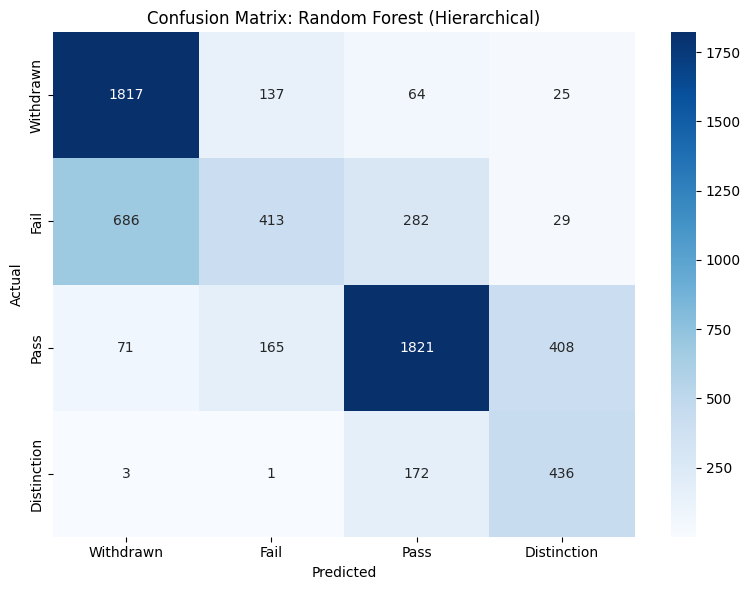

In [9]:
# Threshold tuning trên validation cho RF
proba_v_m1  = rf_m1.predict_proba(X_val_scl)[:, 1]
proba_v_m2a = rf_m2a.predict_proba(X_val_scl[mask_f_val])[:, 1]
proba_v_m2b = rf_m2b.predict_proba(X_val_scl[mask_s_val])[:, 1]

t_rf_1,  _ = tune_threshold(proba_v_m1,  y_val_m1, target_recall=0.85)
t_rf_2a, _ = tune_threshold(proba_v_m2a, y_val_m2a)
t_rf_2b, _ = tune_threshold(proba_v_m2b, y_val_m2b)
print(f"RF thresholds: t1={t_rf_1:.3f}, t2a={t_rf_2a:.3f}, t2b={t_rf_2b:.3f}")

# Predict 4-class trên test
y_pred_rf = hierarchical_predict(X_test_scl, rf_m1, rf_m2a, rf_m2b,
                                   t_rf_1, t_rf_2a, t_rf_2b)

print("\n=== Random Forest Hierarchical — Test Results ===")
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES, digits=4))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix: Random Forest (Hierarchical)")
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

## 5. XGBoost — HierarchicalTrain 3 XGB binary với GPU. Mỗi binary có `scale_pos_weight` đúng (binary classification).

In [10]:
def train_xgb_binary(X_tr, y_tr_bin, X_v, y_v_bin, n_trials=50, name='XGB'):
    print(f"\n[{name}] Training XGBoost (binary)...")
    pos = y_tr_bin.sum()
    neg = len(y_tr_bin) - pos
    spw = neg / pos
    print(f"  pos={pos}, neg={neg}, scale_pos_weight={spw:.3f}")

    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 200, 800),
            'max_depth':        trial.suggest_int('max_depth', 3, 10),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        }
        model = XGBClassifier(
            **params, objective='binary:logistic', eval_metric='auc',
            scale_pos_weight=spw, tree_method='hist', device='cuda',
            random_state=RANDOM_SEED, early_stopping_rounds=20, verbosity=0
        )
        model.fit(X_tr, y_tr_bin, eval_set=[(X_v, y_v_bin)], verbose=False)
        return roc_auc_score(y_v_bin, model.predict_proba(X_v)[:, 1])

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    final = XGBClassifier(
        **study.best_params, objective='binary:logistic', eval_metric='auc',
        scale_pos_weight=spw, tree_method='hist', device='cuda',
        random_state=RANDOM_SEED, verbosity=0
    )
    final.fit(X_tr, y_tr_bin, verbose=False)
    print(f"  [{name}] Val AUC: {study.best_value:.4f}")
    return final, study.best_value

t0 = time.time()

# Stage 1: Failed vs Succeeded
y_tr_m1, y_val_m1, y_test_m1 = targets['m1']
# Stage 2A: chỉ trên Failed
y_tr_m2a, y_val_m2a, mask_f_tr, mask_f_val = targets['m2a']
# Stage 2B: chỉ trên Succeeded
y_tr_m2b, y_val_m2b, mask_s_tr, mask_s_val = targets['m2b']

xgb_m1,  auc_xgb_m1  = train_xgb_binary(X_tr_raw, y_tr_m1, X_val_raw, y_val_m1, name='XGB-M1')
xgb_m2a, auc_xgb_m2a = train_xgb_binary(X_tr_raw[mask_f_tr], y_tr_m2a,
                                          X_val_raw[mask_f_val], y_val_m2a, name='XGB-M2A')
xgb_m2b, auc_xgb_m2b = train_xgb_binary(X_tr_raw[mask_s_tr], y_tr_m2b,
                                          X_val_raw[mask_s_val], y_val_m2b, name='XGB-M2B')

print(f"\n✓ XGB Hierarchical training done. Total time: {time.time()-t0:.1f}s")
print(f"  AUCs: M1={auc_xgb_m1:.4f} | M2A={auc_xgb_m2a:.4f} | M2B={auc_xgb_m2b:.4f}")


[XGB-M1] Training XGBoost (binary)...
  pos=11692, neg=10461, scale_pos_weight=0.895
  [XGB-M1] Val AUC: 0.9767

[XGB-M2A] Training XGBoost (binary)...
  pos=6896, neg=4796, scale_pos_weight=0.695
  [XGB-M2A] Val AUC: 0.8245

[XGB-M2B] Training XGBoost (binary)...
  pos=2050, neg=8411, scale_pos_weight=4.103
  [XGB-M2B] Val AUC: 0.8954

✓ XGB Hierarchical training done. Total time: 196.3s
  AUCs: M1=0.9767 | M2A=0.8245 | M2B=0.8954


XGB thresholds: t1=0.400, t2a=0.240, t2b=0.520

=== XGBoost Hierarchical — Test Results ===
              precision    recall  f1-score   support

   Withdrawn     0.7140    0.8992    0.7959      2043
        Fail     0.6133    0.3262    0.4259      1410
        Pass     0.8017    0.7675    0.7842      2465
 Distinction     0.5207    0.7206    0.6045       612

    accuracy                         0.7090      6530
   macro avg     0.6624    0.6784    0.6527      6530
weighted avg     0.7072    0.7090    0.6937      6530



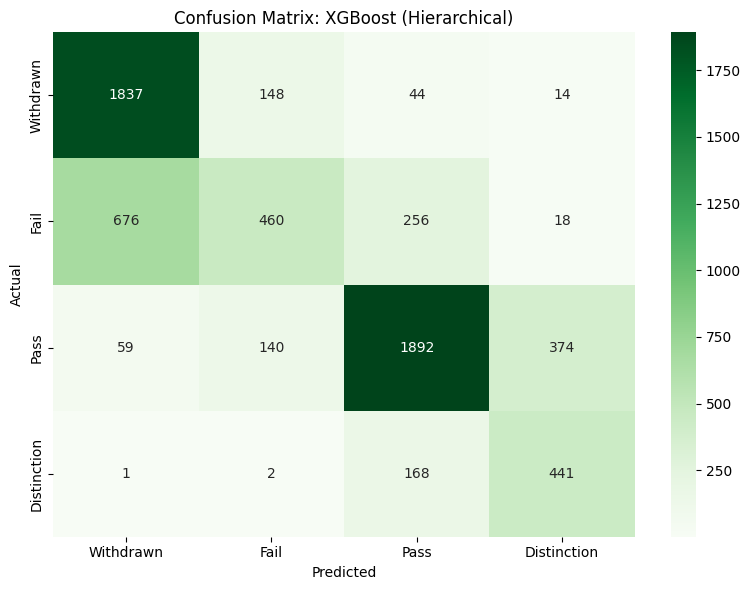

In [11]:
# Threshold tuning trên validation cho XGBoost
proba_v_m1  = xgb_m1.predict_proba(X_val_raw)[:, 1]
proba_v_m2a = xgb_m2a.predict_proba(X_val_raw[mask_f_val])[:, 1]
proba_v_m2b = xgb_m2b.predict_proba(X_val_raw[mask_s_val])[:, 1]

t_xgb_1,  _ = tune_threshold(proba_v_m1,  y_val_m1, target_recall=0.85)
t_xgb_2a, _ = tune_threshold(proba_v_m2a, y_val_m2a)
t_xgb_2b, _ = tune_threshold(proba_v_m2b, y_val_m2b)
print(f"XGB thresholds: t1={t_xgb_1:.3f}, t2a={t_xgb_2a:.3f}, t2b={t_xgb_2b:.3f}")

y_pred_xgb = hierarchical_predict(X_test_raw, xgb_m1, xgb_m2a, xgb_m2b,
                                    t_xgb_1, t_xgb_2a, t_xgb_2b)

print("\n=== XGBoost Hierarchical — Test Results ===")
print(classification_report(y_test, y_pred_xgb, target_names=CLASS_NAMES, digits=4))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix: XGBoost (Hierarchical)")
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

## 6. LightGBM — Hierarchical

In [12]:
def train_lgb_binary(X_tr, y_tr_bin, X_v, y_v_bin, n_trials=50, name='LGB'):
    print(f"\n[{name}] Training LightGBM (binary)...")
    pos = y_tr_bin.sum()
    neg = len(y_tr_bin) - pos
    spw = neg / pos
    print(f"  pos={pos}, neg={neg}, scale_pos_weight={spw:.3f}")

    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 200, 800),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'num_leaves':       trial.suggest_int('num_leaves', 20, 150),
            'max_depth':        trial.suggest_int('max_depth', 3, 12),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        }
        model = LGBMClassifier(
            **params, objective='binary', metric='auc',
            scale_pos_weight=spw, device_type='gpu',
            random_state=RANDOM_SEED, verbose=-1
        )
        model.fit(X_tr, y_tr_bin, eval_set=[(X_v, y_v_bin)],
                  callbacks=[lgb.early_stopping(20, verbose=False)])
        return roc_auc_score(y_v_bin, model.predict_proba(X_v)[:, 1])

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    final = LGBMClassifier(
        **study.best_params, objective='binary', metric='auc',
        scale_pos_weight=spw, device_type='gpu',
        random_state=RANDOM_SEED, verbose=-1
    )
    final.fit(X_tr, y_tr_bin)
    print(f"  [{name}] Val AUC: {study.best_value:.4f}")
    return final, study.best_value


t0 = time.time()
lgb_m1,  auc_lgb_m1  = train_lgb_binary(X_tr_raw, y_tr_m1, X_val_raw, y_val_m1, name='LGB-M1')
lgb_m2a, auc_lgb_m2a = train_lgb_binary(X_tr_raw[mask_f_tr], y_tr_m2a,
                                          X_val_raw[mask_f_val], y_val_m2a, name='LGB-M2A')
lgb_m2b, auc_lgb_m2b = train_lgb_binary(X_tr_raw[mask_s_tr], y_tr_m2b,
                                          X_val_raw[mask_s_val], y_val_m2b, name='LGB-M2B')

print(f"\n✓ LGB Hierarchical training done. Total time: {time.time()-t0:.1f}s")
print(f"  AUCs: M1={auc_lgb_m1:.4f} | M2A={auc_lgb_m2a:.4f} | M2B={auc_lgb_m2b:.4f}")


[LGB-M1] Training LightGBM (binary)...
  pos=11692, neg=10461, scale_pos_weight=0.895
  [LGB-M1] Val AUC: 0.9769

[LGB-M2A] Training LightGBM (binary)...
  pos=6896, neg=4796, scale_pos_weight=0.695
  [LGB-M2A] Val AUC: 0.8246

[LGB-M2B] Training LightGBM (binary)...
  pos=2050, neg=8411, scale_pos_weight=4.103
  [LGB-M2B] Val AUC: 0.8962

✓ LGB Hierarchical training done. Total time: 524.6s
  AUCs: M1=0.9769 | M2A=0.8246 | M2B=0.8962


LGB thresholds: t1=0.380, t2a=0.240, t2b=0.240

=== LightGBM Hierarchical — Test Results ===
              precision    recall  f1-score   support

   Withdrawn     0.6927    0.9158    0.7888      2043
        Fail     0.5985    0.2801    0.3816      1410
        Pass     0.8048    0.7278    0.7644      2465
 Distinction     0.4851    0.7451    0.5876       612

    accuracy                         0.6916      6530
   macro avg     0.6453    0.6672    0.6306      6530
weighted avg     0.6952    0.6916    0.6728      6530



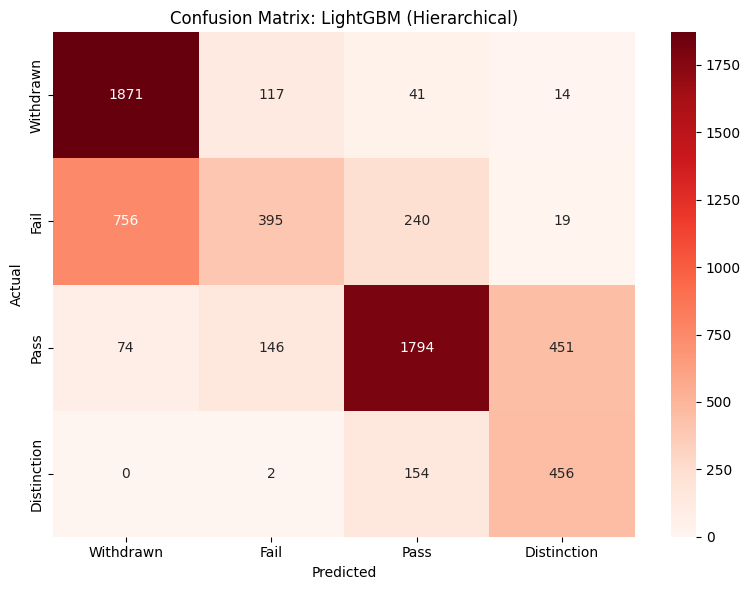

In [13]:
# Threshold tuning trên validation cho LightGBM
proba_v_m1  = lgb_m1.predict_proba(X_val_raw)[:, 1]
proba_v_m2a = lgb_m2a.predict_proba(X_val_raw[mask_f_val])[:, 1]
proba_v_m2b = lgb_m2b.predict_proba(X_val_raw[mask_s_val])[:, 1]

t_lgb_1,  _ = tune_threshold(proba_v_m1,  y_val_m1, target_recall=0.85)
t_lgb_2a, _ = tune_threshold(proba_v_m2a, y_val_m2a)
t_lgb_2b, _ = tune_threshold(proba_v_m2b, y_val_m2b)
print(f"LGB thresholds: t1={t_lgb_1:.3f}, t2a={t_lgb_2a:.3f}, t2b={t_lgb_2b:.3f}")

y_pred_lgb = hierarchical_predict(X_test_raw, lgb_m1, lgb_m2a, lgb_m2b,
                                    t_lgb_1, t_lgb_2a, t_lgb_2b)

print("\n=== LightGBM Hierarchical — Test Results ===")
print(classification_report(y_test, y_pred_lgb, target_names=CLASS_NAMES, digits=4))

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred_lgb), annot=True, fmt='d', cmap='Reds',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix: LightGBM (Hierarchical)")
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

## 7. Threshold Grid Search 3D — Best ModelTìm threshold (t1, t2a, t2b) tối ưu **F1 weighted** trên validation.Áp dụng cho model có AUC trung bình cao nhất.

In [14]:
# Pick model có AUC tổng cao nhất để grid search threshold
auc_avg = {
    'RF':  (auc_rf_m1  + auc_rf_m2a  + auc_rf_m2b)  / 3,
    'XGB': (auc_xgb_m1 + auc_xgb_m2a + auc_xgb_m2b) / 3,
    'LGB': (auc_lgb_m1 + auc_lgb_m2a + auc_lgb_m2b) / 3,
}
print("Average AUC across stages:")
for k, v in auc_avg.items():
    print(f"  {k}: {v:.4f}")

best_model_name = max(auc_avg, key=auc_avg.get)
print(f"\n>>> Best model overall: {best_model_name}")

# Pick model + data
if best_model_name == 'RF':
    m1, m2a, m2b = rf_m1, rf_m2a, rf_m2b
    X_val_use, X_test_use = X_val_scl, X_test_scl
elif best_model_name == 'XGB':
    m1, m2a, m2b = xgb_m1, xgb_m2a, xgb_m2b
    X_val_use, X_test_use = X_val_raw, X_test_raw
else:  # LGB
    m1, m2a, m2b = lgb_m1, lgb_m2a, lgb_m2b
    X_val_use, X_test_use = X_val_raw, X_test_raw

# Grid search 3D
print(f"\nGrid search 3D thresholds for {best_model_name}...")
t0 = time.time()
best_f1w = 0
best_thresholds = None
results = []

t1_grid  = np.arange(0.30, 0.65, 0.05)
t2a_grid = np.arange(0.30, 0.70, 0.05)
t2b_grid = np.arange(0.20, 0.60, 0.05)

for tt1 in t1_grid:
    for tt2a in t2a_grid:
        for tt2b in t2b_grid:
            yp = hierarchical_predict(X_val_use, m1, m2a, m2b, tt1, tt2a, tt2b)
            f1w   = f1_score(y_val, yp, average='weighted')
            f1m   = f1_score(y_val, yp, average='macro')
            rec_w = recall_score(y_val, yp, labels=[0], average='macro')
            results.append({'t1':tt1,'t2a':tt2a,'t2b':tt2b,
                            'f1_weighted':f1w,'f1_macro':f1m,'recall_W':rec_w})
            if f1w > best_f1w:
                best_f1w = f1w
                best_thresholds = (tt1, tt2a, tt2b)

df_grid = pd.DataFrame(results)
print(f"  Grid search done in {time.time()-t0:.1f}s ({len(results)} configs tried)")
print(f"\n>>> Best F1 weighted (val): {best_f1w:.4f}")
print(f">>> at t1={best_thresholds[0]:.2f}, t2a={best_thresholds[1]:.2f}, t2b={best_thresholds[2]:.2f}")
print("\nTop 5 configs by F1 weighted:")
print(df_grid.sort_values('f1_weighted', ascending=False).head(5).to_string(index=False))

Average AUC across stages:
  RF: 0.8905
  XGB: 0.8989
  LGB: 0.8992

>>> Best model overall: LGB

Grid search 3D thresholds for LGB...
  Grid search done in 316.9s (448 configs tried)

>>> Best F1 weighted (val): 0.7206
>>> at t1=0.35, t2a=0.45, t2b=0.55

Top 5 configs by F1 weighted:
  t1  t2a  t2b  f1_weighted  f1_macro  recall_W
0.35 0.45 0.55     0.720564  0.679183  0.789647
0.55 0.55 0.55     0.720290  0.679085  0.709942
0.35 0.55 0.55     0.720188  0.681192  0.714873
0.55 0.45 0.55     0.720101  0.676429  0.782251
0.55 0.60 0.55     0.719909  0.680080  0.670501


FINAL — LGB Hierarchical with Tuned Thresholds
Thresholds: t1=0.350, t2a=0.450, t2b=0.550

              precision    recall  f1-score   support

   Withdrawn     0.7722    0.8032    0.7874      2043
        Fail     0.5675    0.5128    0.5387      1410
        Pass     0.7848    0.8154    0.7998      2465
 Distinction     0.5965    0.5556    0.5753       612

    accuracy                         0.7219      6530
   macro avg     0.6803    0.6717    0.6753      6530
weighted avg     0.7163    0.7219    0.7185      6530


>>> F1 macro:           0.6753
>>> F1 weighted:        0.7185
>>> Accuracy:           0.7219
>>> Recall(Withdrawn):  0.8032


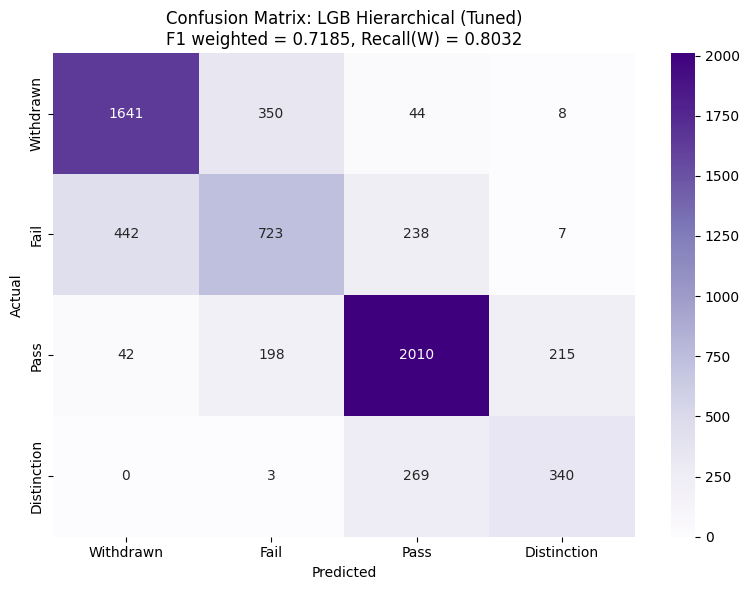

In [15]:
# Final eval với tuned thresholds
bt1, bt2a, bt2b = best_thresholds
y_pred_tuned = hierarchical_predict(X_test_use, m1, m2a, m2b, bt1, bt2a, bt2b)

print("=" * 70)
print(f"FINAL — {best_model_name} Hierarchical with Tuned Thresholds")
print("=" * 70)
print(f"Thresholds: t1={bt1:.3f}, t2a={bt2a:.3f}, t2b={bt2b:.3f}")
print()
print(classification_report(y_test, y_pred_tuned, target_names=CLASS_NAMES, digits=4))

f1m_tuned   = f1_score(y_test, y_pred_tuned, average='macro')
f1w_tuned   = f1_score(y_test, y_pred_tuned, average='weighted')
acc_tuned   = accuracy_score(y_test, y_pred_tuned)
recw_tuned  = recall_score(y_test, y_pred_tuned, labels=[0], average='macro')

print(f"\n>>> F1 macro:           {f1m_tuned:.4f}")
print(f">>> F1 weighted:        {f1w_tuned:.4f}")
print(f">>> Accuracy:           {acc_tuned:.4f}")
print(f">>> Recall(Withdrawn):  {recw_tuned:.4f}")

plt.figure(figsize=(8,6))
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f"Confusion Matrix: {best_model_name} Hierarchical (Tuned)\n"
          f"F1 weighted = {f1w_tuned:.4f}, Recall(W) = {recw_tuned:.4f}")
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

## 8. Model ComparisonSo sánh 3 models hierarchical (default thresholds) + best tuned model.

MODEL COMPARISON — Hierarchical Approaches
                       Accuracy  F1 macro  F1 weighted  Recall(W)
RF Hierarchical          0.6871    0.6277       0.6703     0.8894
XGBoost Hierarchical     0.7090    0.6527       0.6937     0.8992
LightGBM Hierarchical    0.6916    0.6306       0.6728     0.9158
LGB (Tuned)              0.7219    0.6753       0.7185     0.8032

>>> WINNER (F1 weighted): LGB (Tuned) (0.7185)


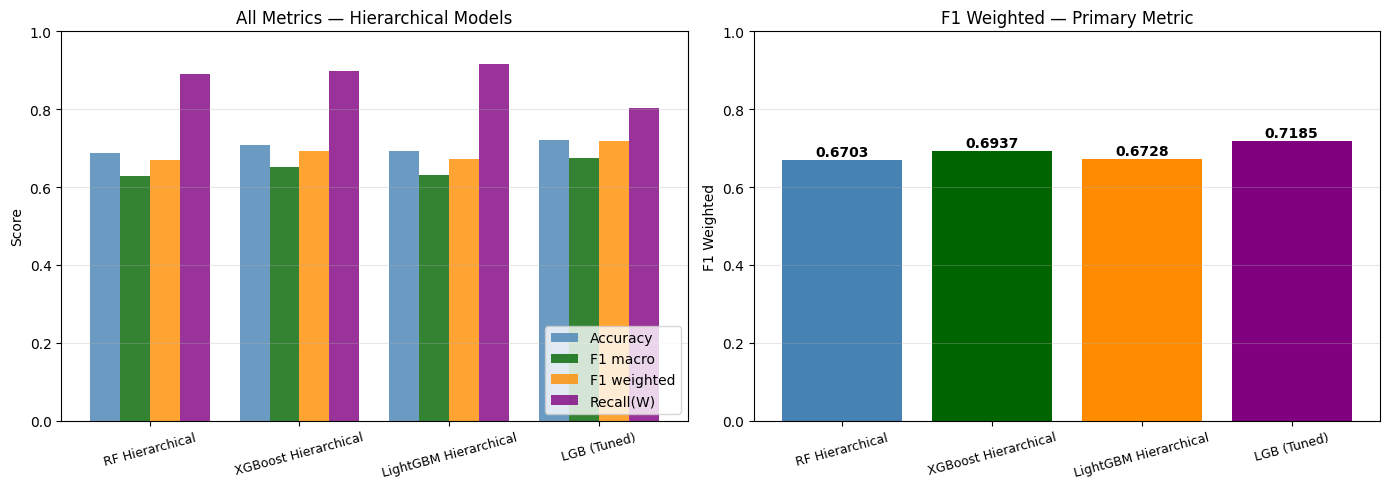

In [16]:
# 1. Calculate all metrics
def all_metrics(y_true, y_pred):
    return {
        'Accuracy':    accuracy_score(y_true, y_pred),
        'F1 macro':    f1_score(y_true, y_pred, average='macro'),
        'F1 weighted': f1_score(y_true, y_pred, average='weighted'),
        'Recall(W)':   recall_score(y_true, y_pred, labels=[0], average='macro'),
    }

results_all = {
    'RF Hierarchical':       all_metrics(y_test, y_pred_rf),
    'XGBoost Hierarchical':  all_metrics(y_test, y_pred_xgb),
    'LightGBM Hierarchical': all_metrics(y_test, y_pred_lgb),
    f'{best_model_name} (Tuned)': all_metrics(y_test, y_pred_tuned),
}

df_summary = pd.DataFrame(results_all).T.round(4)
print("=" * 70)
print("MODEL COMPARISON — Hierarchical Approaches")
print("=" * 70)
print(df_summary.to_string())

# Determine winner by F1 weighted
winner_name = df_summary['F1 weighted'].idxmax()
winner_score = df_summary.loc[winner_name, 'F1 weighted']
print(f"\n>>> WINNER (F1 weighted): {winner_name} ({winner_score:.4f})")

# 2. Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_to_plot = ['Accuracy', 'F1 macro', 'F1 weighted', 'Recall(W)']
colors = ['steelblue', 'darkgreen', 'darkorange', 'purple']
x = np.arange(len(df_summary))
width = 0.2

for i, metric in enumerate(metrics_to_plot):
    axes[0].bar(x + i*width, df_summary[metric], width,
                label=metric, color=colors[i], alpha=0.8)
axes[0].set_xticks(x + 1.5*width)
axes[0].set_xticklabels(df_summary.index, rotation=15, fontsize=9)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics — Hierarchical Models')
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1)

# F1 weighted standalone
bars = axes[1].bar(df_summary.index, df_summary['F1 weighted'],
                    color=['steelblue','darkgreen','darkorange','purple'])
axes[1].set_ylabel('F1 Weighted')
axes[1].set_title('F1 Weighted — Primary Metric')
axes[1].set_ylim(0, 1)
for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.4f}',
                 ha='center', fontweight='bold')
axes[1].set_xticklabels(df_summary.index, rotation=15, fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Per-stage AUC — DiagnosticBảng AUC của mỗi model × mỗi stage. Giúp identify weak link.

Per-stage Validation AUC:
          Stage 1 (Failed vs Succeeded)  Stage 2A (Withdrawn vs Fail)  Stage 2B (Pass vs Distinction)
RF                               0.9684                        0.8139                          0.8892
XGBoost                          0.9767                        0.8245                          0.8954
LightGBM                         0.9769                        0.8246                          0.8962

Average AUC per model:
  RF: 0.8905
  XGB: 0.8989
  LGB: 0.8992


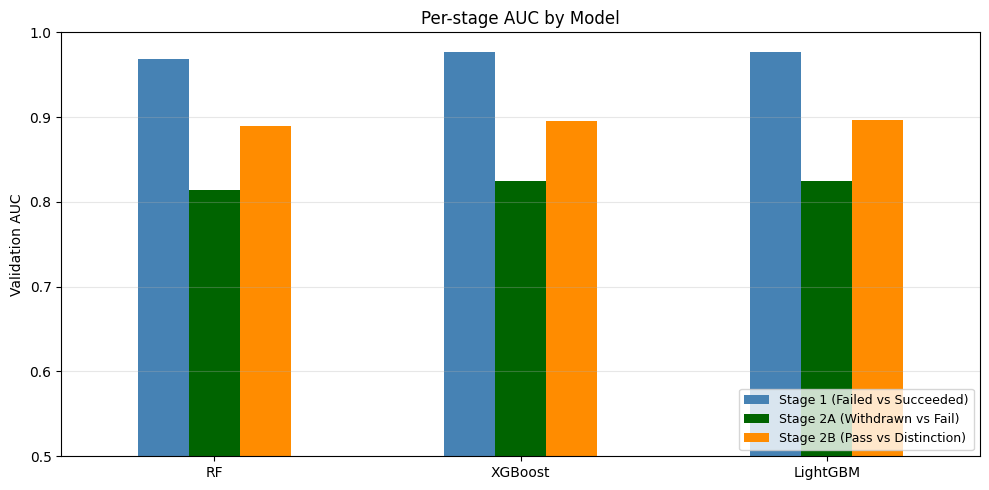

In [17]:
auc_table = pd.DataFrame({
    'Stage 1 (Failed vs Succeeded)':     [auc_rf_m1,  auc_xgb_m1,  auc_lgb_m1],
    'Stage 2A (Withdrawn vs Fail)':       [auc_rf_m2a, auc_xgb_m2a, auc_lgb_m2a],
    'Stage 2B (Pass vs Distinction)':     [auc_rf_m2b, auc_xgb_m2b, auc_lgb_m2b],
}, index=['RF', 'XGBoost', 'LightGBM']).round(4)

print("Per-stage Validation AUC:")
print(auc_table.to_string())
print(f"\nAverage AUC per model:")
for name, val in auc_avg.items():
    print(f"  {name}: {val:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
auc_table.plot(kind='bar', ax=ax, color=['steelblue','darkgreen','darkorange'])
ax.set_ylabel('Validation AUC')
ax.set_title('Per-stage AUC by Model')
ax.set_ylim(0.5, 1.0)
ax.legend(loc='lower right', fontsize=9)
ax.set_xticklabels(auc_table.index, rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()